# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import re
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 My own Text Corpus
The corpus describe my Internship journey at Celebal technologies

In [ ]:
corpus = '''
I am Tanu Jain currently pursuing Btech and working as a Data Science Intern at Celebal Technologies
My internship experience so far has been very enriching because I have been working on
machine learning assignments covering areas like regression time series clustering
and image classification It has helped me understand how to move from concepts to actual implementation and analysis
'''
# convert to lowercase
corpus = corpus.lower()

print(corpus)


i am tanu jain currently pursuing btech and working as a data science intern at celebal technologies
my internship experience so far has been very enriching because i have been working on
machine learning assignments covering areas like regression time series clustering
and image classification it has helped me understand how to move from concepts to actual implementation and analysis



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 54
X shape: (56, 17)
y shape: (56,)


# 🧠 Model 1: Baseline Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.


LSTM is an advanced recurrent architecture designed to handle long-term dependencies using gating mechanisms. It is expected to perform better than Vanilla RNN in text generation tasks because it can preserve contextual memory over longer sequences.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

GRU is a gated recurrent unit that provides a simpler alternative to LSTM while still capturing long-term contextual dependencies effectively.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss (over 100 epochs)

The training loss of all three models is plotted to compare optimization behavior and stabilization speed. Lower and faster-reducing loss indicates more effective learning of sequence patterns from the corpus.

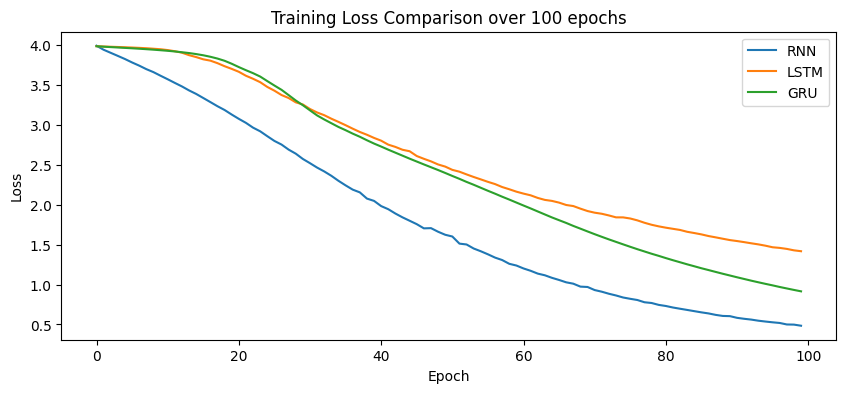

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison over 100 epochs")
plt.legend()
plt.show()

## **Modified Vanilla RNN Model**

Here we apply student modifications:

- Embedding 32 → 64
- Hidden units 64 → 128
- Epochs 100 → 200

In [ ]:
modified_rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

modified_rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

modified_rnn_history = modified_rnn_model.fit(X, y, epochs=200, verbose=0)
print("Modified Vanilla RNN training completed")

Modified Vanilla RNN training completed


## **Modified LSTM Model**
Here we apply student modifications:

- Embedding 32 → 64
- Hidden units 64 → 128
- Epochs 100 → 200

In [ ]:
modified_lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

modified_lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

modified_lstm_history = modified_lstm_model.fit(X, y, epochs=200, verbose=0)
print("Modified LSTM training completed")

Modified LSTM training completed


## **Modified GRU Model**
Here we apply student modifications:

- Embedding 32 → 64
- Hidden units 64 → 128
- Epochs 100 → 200

In [ ]:
modified_gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

modified_gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

modified_gru_history = modified_gru_model.fit(X, y, epochs=200, verbose=0)
print("Modified GRU training completed")

Modified GRU training completed


## 📉 Compare Training Loss in modified models

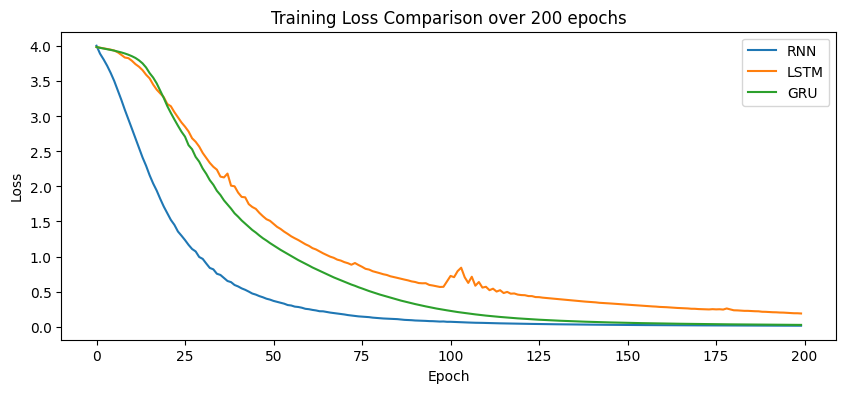

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(modified_rnn_history.history['loss'], label='RNN')
plt.plot(modified_lstm_history.history['loss'], label='LSTM')
plt.plot(modified_gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison over 200 epochs")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.
- The `generate_text()` function predicts one word at a time based on a given seed phrase.
- At each step, the model outputs a probability distribution over the vocabulary
- `np.argmax()` is used to select the most probable next word.
- This process is repeated to generate a complete text sequence.

As mentioned in Student tasks we adjust output to return 10 words per generation prompt.

In [ ]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples (using baseline models)

In [ ]:
print("RNN :", generate_text(rnn_model, "my", 10))
print("LSTM:", generate_text(lstm_model, "my", 10))
print("GRU :", generate_text(gru_model, "my", 10))

RNN : my internship experience so far has been very enriching because i
LSTM: my internship image so has has has very enriching because i
GRU : my internship experience so far has been very enriching because i


## 🧪 Generate Text Samples (using modified models)

In [ ]:
print("RNN :", generate_text(modified_rnn_model, "my", 10))
print("LSTM:", generate_text(modified_lstm_model, "my", 10))
print("GRU :", generate_text(modified_gru_model, "my", 10))

RNN : my internship experience so far has been very enriching because i
LSTM: my internship experience so far has been very enriching because i
GRU : my internship experience so far has been very enriching because i


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph   -- Done✅
2. Increase embedding dimension             -- Done✅
3. Increase epochs to 200                   -- Done✅
4. Change hidden units 64 → 128             -- Done✅
5. Generate 10 words instead of 5           -- Done✅

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps understanding **sequence modeling mathematically and practically**